# Local Spatial Autocorrelation with Moran's $I_i$

This notebook  focuses on local indicators of spatial association (LISA).

## Learning goals

By the end of this notebook, you will be able to:

- compute local Moran statistics for each areal unit
- interpret the Moran scatterplot quadrants
- identify statistically significant hot spots, cold spots, and spatial outliers
- distinguish global evidence of autocorrelation from local patterns

Local indicators of spatial association (LISA) answer the question that global Moran's $I$ cannot: **where** is the clustering occurring?


In [94]:
import geopandas as gpd
import libpysal as lps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import esda

Our data set comes from the Berlin airbnb scrape taken in April 2018. This dataframe was constructed as part of the [GeoPython 2018 workshop](https://github.com/ljwolf/geopython) by [Levi Wolf](https://ljwolf.org) and [Serge Rey](https://sergerey.org). As part of the workshop a geopandas data frame was constructed with one of the columns reporting the median listing price of units in each neighborhood in Berlin:

## Data preparation

We use the same Berlin neighborhood data and median Airbnb price variable as in the global analysis. Keeping the data and weights constant makes it easier to connect the local results back to the global Moran's $I$ statistic.


In [95]:
gdf = gpd.read_file("data/berlin-housing.gpkg")

<Axes: >

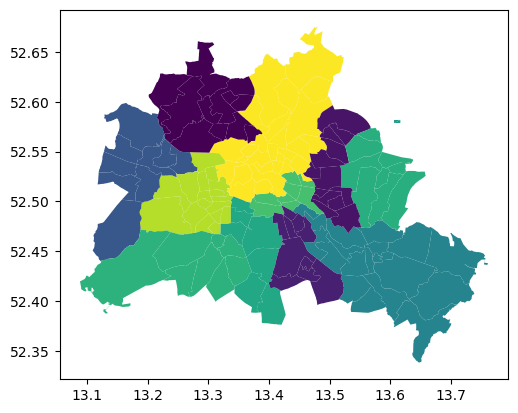

In [96]:
gdf.plot(column="median_pri")

<Axes: >

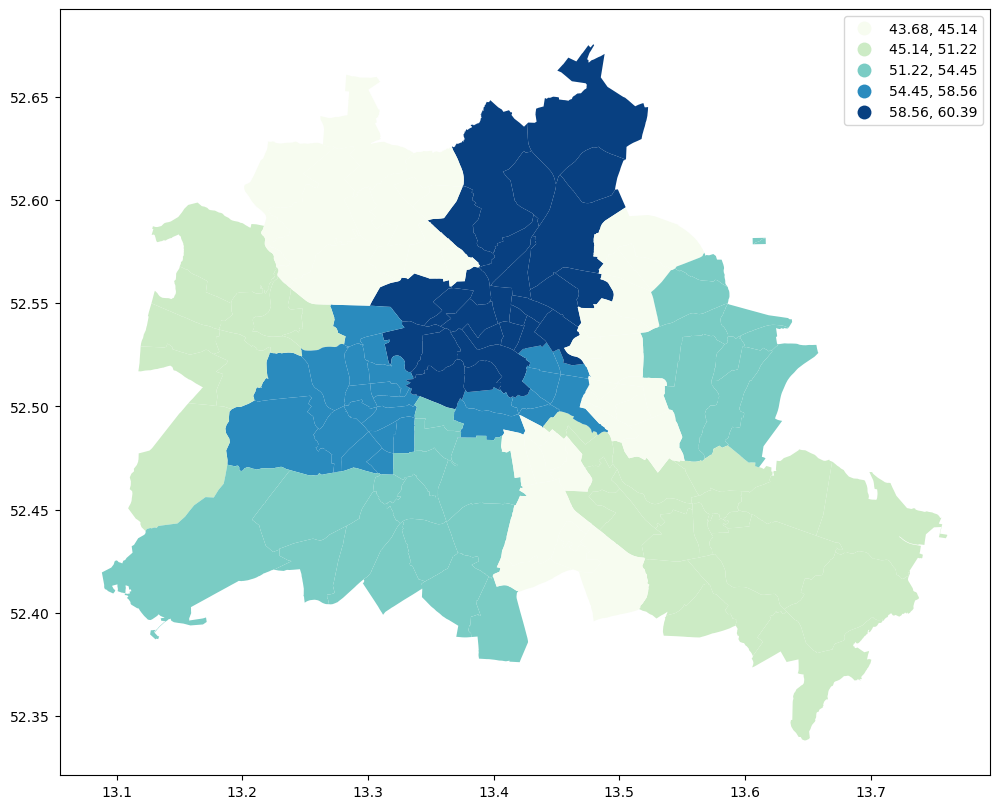

In [97]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"aspect": "equal"})
gdf.plot(column="median_pri", scheme="Quantiles", k=5, cmap="GnBu", legend=True, ax=ax)
# ax.set_xlim(150000, 160000)
# ax.set_ylim(208000, 215000)

## From global to local autocorrelation

A significant global statistic tells us that the map is spatially structured overall, but it does not reveal which neighborhoods are driving that result. Local Moran statistics decompose that global pattern into unit-level contributions.


## Local Spatial Autocorrelation

In [98]:
df = gdf
wq = lps.weights.Queen.from_dataframe(df, use_index=False, silence_warnings=True)
wq.transform = "r"

In [99]:
y = df["median_pri"]
ylag = lps.weights.lag_spatial(wq, y)

The Moran scatterplot is a useful bridge between visualization and inference. It relates each neighborhood's value to the average value of its neighbors and organizes the observations into the familiar four quadrants of high-high, low-low, high-low, and low-high association. The `Moran_Local` class can be used to calculate the Local Moran statistic and provide various visualizations, including the scatterplot.


In [100]:
wq.transform = "r"
lag_price = lps.weights.lag_spatial(wq, df["median_pri"])

In [101]:
lmi = esda.moran.Moran_Local(df['median_pri'], wq, seed=12345)

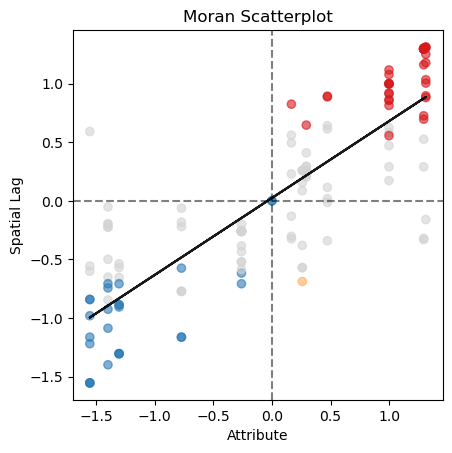

In [102]:
lmi.plot_scatter();

In addition to the scatterplot, the `lmi` object can produce a cluster map:

<Axes: >

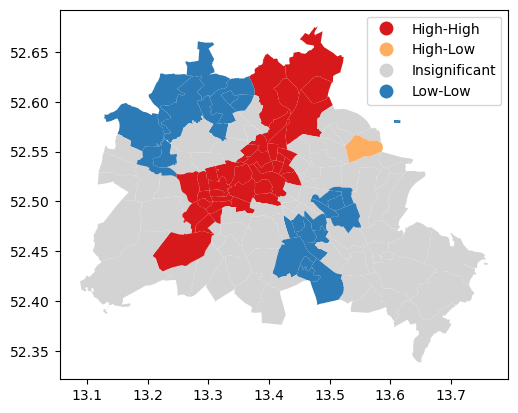

In [103]:
lmi.plot(gdf, legend=True)

### Interpreting cluster types

The quadrant labels correspond to substantively different local relationships:

- **High-High**: a hot spot
- **Low-Low**: a cold spot
- **High-Low**: a high-value spatial outlier
- **Low-High**: a low-value spatial outlier

In practice, we usually map only those observations that are statistically significant under the permutation test.
The permutation test is discussed in more detail below.


The `Moran_Local` object can also provide a composite visualization that combines the scatterplot, cluster map, and a choropleth of the variable of interest:

array([<Axes: title={'center': 'Moran Scatterplot'}, xlabel='Attribute', ylabel='Spatial Lag'>,
       <Axes: >, <Axes: >], dtype=object)

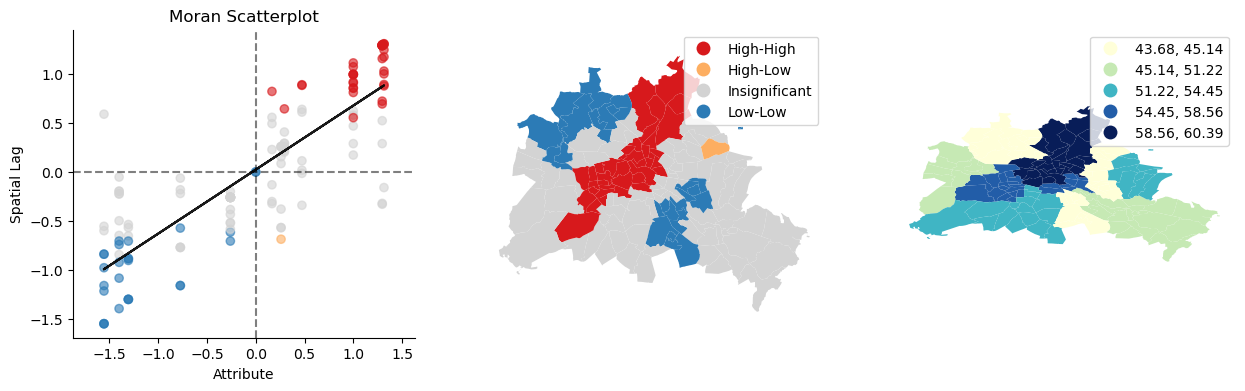

In [104]:
lmi.plot_combination(gdf, 'median_pri')

## Approaches for Inference & Conditional Permutations

To determine whether a local spatial cluster (Hot Spot/Cold Spot) or outlier (Spatial Outlier) is statistically significant, we must evaluate its localized value against a null hypothesis. In spatial autocorrelation, the standard null hypothesis is **Spatial Randomness**: the assumption that the observed values are distributed entirely at random across the map, independent of geographic location.

Because the theoretical sampling distribution of local statistics like local Moran's $I_i$ can be highly complex and non-normal, two primary approaches are used for inference:

1. **Analytical Inference:** Assumes the local statistic follows an asymptotic normal distribution. This is computationally fast but relies on structural assumptions that often fail in small samples or highly skewed spatial layouts.
2. **Computational Inference (Conditional Permutations):** Instead of assuming an idealized distribution, a simulated null distribution is constructed empirically.

### The Logic of Conditional Spatial Permutations

Global permutations reshuffle every value across the entire map. However, this is invalid for *local* statistics because the value of the target location $i$ is structurally bound to the calculation. If it is included in the shuffle, we alter the very baseline we are testing. 

To overcome this, **Conditional Spatial Permutation** operates via the following explicit steps for each areal unit $i$:

1. **Freeze the Core:** The observed value $y_i$ at the target location $i$ is held constant ("conditioned" upon).
2. **Permit the Environment:** The remaining $N-1$ values in the dataset are randomly reshuffled across all other spatial positions except $i$.
3. **Compute Pseudo-Statistics:** The local Moran's $I_i$ is recalculated using the fixed $y_i$ and the newly randomized neighboring values.
4. **Iterate:** This process is repeated $M$ times (e.g., $M=999$ or $M=9999$) to build a customized empirical null distribution for *that specific location*.
5. **Calculate the Pseudo $p$-value:** The observed $I_i$ is compared to this simulated distribution:

$$\text{Pseudo } p = \frac{k + 1}{M + 1}$$

Where $k$ is the number of simulated iterations where the absolute pseudo-statistic was as extreme or more extreme than the observed local statistic.

Let's look at how we can implement and examine these empirical distributions using `esda` and `libpysal`.

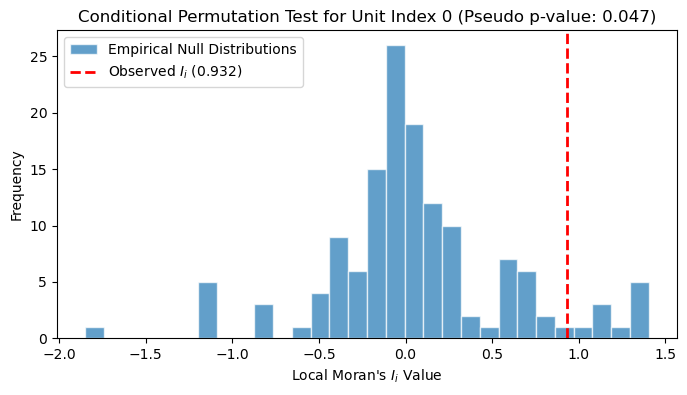

In [105]:

w = lps.weights.Queen.from_dataframe(gdf)
w.transform = 'r'

lm = esda.moran.Moran_Local(gdf['median_pri'], w, permutations=999, seed=12345)

# Visualizing the empirical null distribution for a single neighborhood vs its observed statistic
neighborhood_idx = 0  # Pick the first spatial unit
observed_stat = lm.Is[neighborhood_idx]
simulated_stats = lm.sim[neighborhood_idx]

plt.figure(figsize=(8, 4))
plt.hist(simulated_stats, bins=30, edgecolor='white', alpha=0.7, label='Empirical Null Distributions')
plt.axvline(observed_stat, color='red', linestyle='dashed', linewidth=2, label=f'Observed $I_i$ ({observed_stat:.3f})')
plt.title(f"Conditional Permutation Test for Unit Index {neighborhood_idx} (Pseudo p-value: {lm.p_sim[neighborhood_idx]:.3f})")
plt.xlabel("Local Moran's $I_i$ Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Methodological Issues and Caveats

When conducting local spatial autocorrelation tests, there are three pervasive challenges that must be taken into account during interpretation:

### The Multiple Comparisons Problem
A separate statistical test is conducted for *every single location* on the map (e.g., if you have 140 neighborhoods, you run 140 tests). If you use a standard significance level of $\alpha = 0.05$, you expect roughly 5% of your locations to appear "statistically significant" purely by chance (False Positives / Type I errors).

To prevent over-interpreting random variations as meaningful clusters, alpha adjustments are required:
* **Bonferroni Correction:** A conservative approach where the target alpha is divided by the number of observations ($\alpha_{adj} = \alpha / N$).
* **False Discovery Rate (FDR):** A more flexible approach that controls the expected proportion of false positives among the rejected hypotheses.

### Local Statistics in the Presence of Global Autocorrelation
If a process exhibits strong *global* spatial autocorrelation, the baseline assumption of complete spatial randomness is technically violated from the outset. In a highly clustered map, a local unit's neighbors are likely to be similar simply because the entire map is clustered, not necessarily because that specific location is a unique regional hot spot. This background global trend can artificially inflate the significance of local statistics.

### Spatial Dependence of the Local Tests
Local statistics are inherently dependent on one another due to shared boundaries. If neighborhood A is a neighbor of neighborhood B, the calculation of $I_A$ uses the values of B, and the calculation of $I_B$ uses the values of A. Because their neighbor components overlap heavily across space, the resulting local tests are not independent. This violation of independence invalidates standard parametric interpretation and further solidifies why conditional random permutations are preferred over analytical calculations.

## Takeaways

Local Moran analysis moves from a single global summary to place-specific diagnostics. This is often the most interpretable stage of ESDA because it reveals where clustering and outliers are located on the map. At the same time, these local results should always be interpreted in the context of the global pattern, the choice of spatial weights, and the multiple-testing issues that arise when many local statistics are examined at once.
